In [23]:
import scipy

In [24]:
rSua = 0.009284666666666667
float(84400/150000000)

0.0005626666666666667

In [25]:
distancesmoy_au_soleil = {
    "Mercure": 0.38,
    "Vénus": 0.72,
    "Terre": 1.00,
    "Mars": 1.52,
    "Jupiter": 5.21,
    "Saturne": 9.54,
    "Uranus": 19.18,
    "Neptune": 30.11
}
revol_planetes_j = {
    "Mercure": 87.969,
    "Vénus": 224.701,
    "Terre": 365.257,
    "Mars": 686.96,
    "Jupiter" : 4335.355,
    "Saturne" : 10757.737,
    "Uranus" : 30708.16,
    "Neptune" : 60224.904,
}

vitesse_moyenne_ua_J = {
}
theta_jour = {
    
}

Lune = ("Terre",0.1,27.32,2*pi/27.32)
Deimos = ("Mars", 0.1,1.262, 2*pi/1.262) 
distances_soleil = {}
for i in distancesmoy_au_soleil.keys():
    if distancesmoy_au_soleil[i] < 2:
        distances_soleil[i] = distancesmoy_au_soleil[i]

for i in distances_soleil.keys():
    vitesse_moyenne_ua_J[i] = distances_soleil[i]/revol_planetes_j[i]
    theta_jour[i] = 2*pi/revol_planetes_j[i]
theta_jour 


{'Mercure': 0.0227352817469791*pi,
 'Vénus': 0.00890071695275054*pi,
 'Terre': 0.00547559663469831*pi,
 'Mars': 0.00291137766391056*pi}

Animation with 73 frames
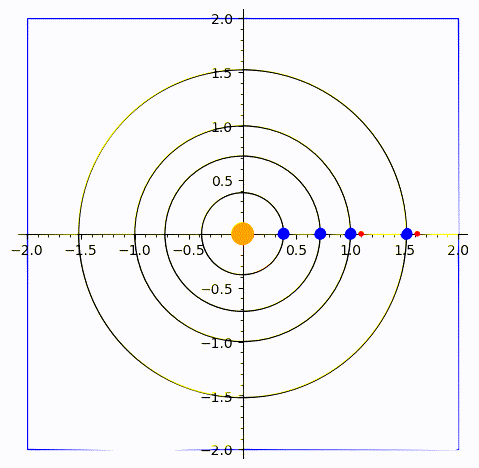

In [26]:
def dessine_planetes(k):
    plt = polygon2d([(-2,-2),(-2,2),(2,2),(2,-2)], fill = False) 
    plt += circle((0,0), 0.1, fill = True, color = "orange")
    angl = {}
    for i in theta_jour.keys():
        angl[i] = 5*k* theta_jour[i]
    for i in distances_soleil.keys():
        plt += circle((0,0), distances_soleil[i] , fill = False, color = "black")
        plt += circle((distances_soleil[i]*cos(angl[i]),distances_soleil[i]*sin(angl[i])), 0.05 , fill = True, color = "blue")

    plt += circle((distances_soleil["Terre"]*cos(angl["Terre"])+Lune[1]*cos(5*k*Lune[3]),distances_soleil["Terre"]*sin(angl["Terre"])+Lune[1]*sin(5*k*Lune[3])), 0.02 , fill = True, color = "red")
    plt += circle((distances_soleil["Mars"]*cos(angl["Mars"])+Deimos[1]*cos(5*k*Deimos[3]),distances_soleil["Mars"]*sin(angl["Mars"])+Deimos[1]*sin(5*k*Deimos[3])), 0.02 , fill = True, color = "red")

    return plt



liste = [dessine_planetes(k) for k in range(73)]

a = animate(liste)
a.show()

In [27]:
ua = 149597887.5
Planetes = {
    "Mercure": {"T_revol_j" :87.969, "Demi_g_axe_km" : 57909050, "Périphélie_km" : 46001200, "Excentricité": 0.2056}, 
    "Vénus": {"T_revol_j" :224.701, "Demi_g_axe_km" : 108209500, "Périphélie_km" : 107476000, "Excentricité": 0.0068},
    "Terre": {"T_revol_j" :365.257, "Demi_g_axe_km" : 149597887.5, "Périphélie_km" : 147098074, "Excentricité": 0.0167}, 
    "Mars": {"T_revol_j" :686.96,"Demi_g_axe_km" : 227944000, "Périphélie_km" : 206655000, "Excentricité": 0.0934}, 
}
for i in Planetes.keys():
    Planetes[i]["C"] =  Planetes[i]["Demi_g_axe_km"] - Planetes[i]["Périphélie_km"]
    Planetes[i]["Demi_g_axe_ua"] =  Planetes[i]["Demi_g_axe_km"]/ua
    Planetes[i]["C_ua"] =  Planetes[i]["C"]/ua
    Planetes[i]["Demi_p_axe_ua"] =  sqrt(Planetes[i]["Demi_g_axe_ua"]**2 - Planetes[i]["C_ua"]**2)



In [41]:
def Kepler_equation(eccentric_anomaly, planet_name):
    e = Planetes[planet_name]["Excentricité"]
    M = eccentric_anomaly - e*sin(eccentric_anomaly)
    return eccentric_anomaly - e*sin(eccentric_anomaly)


def approximativ_position(planet_name, time):
    period = Planetes[planet_name]["T_revol_j"]
    average_anomaly = (2 * pi * time) / period
    e = Planetes[planet_name]["Excentricité"]
    approx_E = average_anomaly+e*sin(average_anomaly)+(1/2)*e**2*sin(2*average_anomaly)
    eccentric_anomaly = scipy.optimize.newton(Kepler_equation, approx_E, args=(planet_name,), tol = 1e-2)
    a = Planetes[planet_name]["Demi_g_axe_km"]
    x = a * (np.cos(eccentric_anomaly) - e)
    y = np.sqrt(1 - e**2) * np.sin(eccentric_anomaly)
    return x, y

In [42]:
def dessine_planetes_ellipse(k):
    plt = polygon2d([(-2,-2),(-2,2),(2,2),(2,-2)], fill = False) 
    plt += circle((0,0), 0.1, fill = True, color = "orange")
    for k in range(0, 5):
        for i in distances_soleil.keys():
            plt += ellipse((-Planetes[i]["C_ua"],0), Planetes[i]["Demi_g_axe_ua"],Planetes[i]["Demi_p_axe_ua"] , pi/2,fill = False, color = "black")
            x, y = approximativ_position(i, k)
            plt += circle((x, y), 0.05 , fill = True, color = "blue")
    return plt
liste = [dessine_planetes_ellipse(k) for k in range(5)]

a = animate(liste)
a.show()


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''